In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [51]:
url = "https://raw.githubusercontent.com/PrathmeshPawale89/my-website/refs/heads/main/Iris.csv"
df = pd.read_csv(url)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [52]:
print(df.shape)
print(df.info())
print(df.describe())

(150, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.5

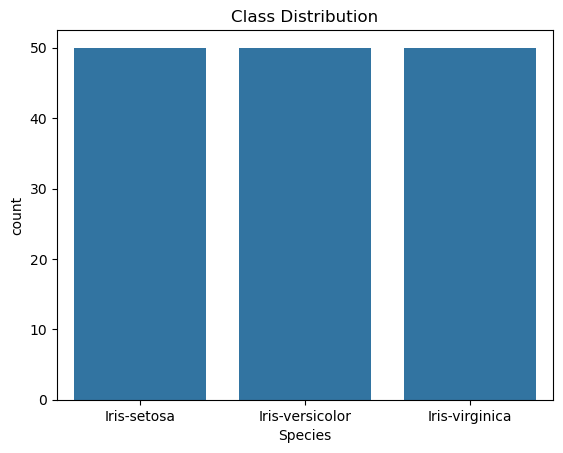

In [54]:
sns.countplot(x=df['Species'])
plt.title("Class Distribution")
plt.show()

In [55]:
X = df.drop('Species', axis=1)
y = df['Species']

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [57]:
model = GaussianNB()
model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [58]:
y_pred = model.predict(X_test)

In [59]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


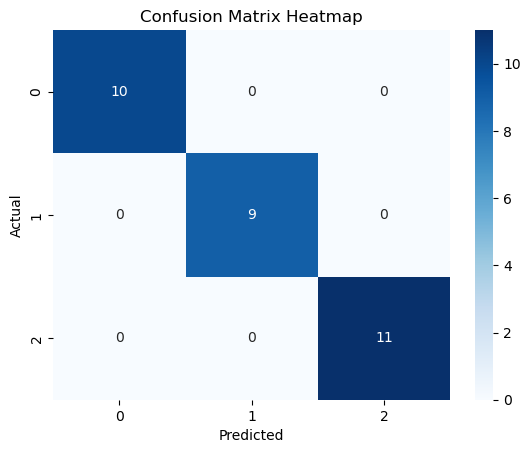

In [60]:
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [61]:
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy

print("Accuracy:", accuracy)
print("Error Rate:", error_rate)

Accuracy: 1.0
Error Rate: 0.0


In [62]:
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [63]:
# For multi-class, metrics are per class
# Let's calculate for one class (example: setosa)

class_index = 0  # setosa

TP = cm[class_index, class_index]
FP = sum(cm[:, class_index]) - TP
FN = sum(cm[class_index, :]) - TP
TN = cm.sum() - (TP + FP + FN)

print("TP:", TP)
print("FP:", FP)
print("FN:", FN)
print("TN:", TN)

TP: 10
FP: 0
FN: 0
TN: 20


In [64]:
print("✅ Practical Executed Successfully: Naïve Bayes Classification on Iris Dataset")

✅ Practical Executed Successfully: Naïve Bayes Classification on Iris Dataset
